In [1]:
from langchain_groq import ChatGroq
import getpass
import os
from langchain_tavily import TavilySearch
from langchain_core.tools import tool
import json
def _set_if_undefined(var:str)-> None:
    if os.environ.get(var):
        return
    os.environ[var] = getpass.getpass(var)
_set_if_undefined("GROQ_API_KEY")
_set_if_undefined("TAVILY_API_KEY")

/Users/anirudh/.local/share/virtualenvs/Desktop-sFnGVMJ4/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GROQ_API_KEY ········
TAVILY_API_KEY ········


In [2]:
llm = ChatGroq(
    model = "llama-3.3-70b-versatile",
    temperature = 0.6,
    max_tokens = 2048
)

In [3]:
response = llm.invoke("Tell me a joke about penguins")
print(response.content)

Why did the penguin take his credit card to the Antarctic?

Because he wanted to freeze his assets!


In [4]:
search = TavilySearch()
@tool
def search_query(query:str):
    
    """Searches the web for current information using the Tavily API."""

    return search.invoke({"query":query})
    
response = search_query.invoke({"query":"Weather in seattle"})   
response

{'query': 'Weather in seattle',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'title': 'Weather in Seattle',
   'url': 'https://www.weatherapi.com/',
   'content': "{'location': {'name': 'Seattle', 'region': 'Washington', 'country': 'United States of America', 'lat': 47.6064, 'lon': -122.3308, 'tz_id': 'America/Los_Angeles', 'localtime_epoch': 1770923745, 'localtime': '2026-02-12 11:15'}, 'current': {'last_updated_epoch': 1770926400, 'last_updated': '2026-02-12 12:00', 'temp_c': 5.6, 'temp_f': 42.1, 'is_day': 1, 'condition': {'text': 'Mist', 'icon': '//cdn.weatherapi.com/weather/64x64/day/143.png', 'code': 1030}, 'wind_mph': 4.5, 'wind_kph': 7.2, 'wind_degree': 185, 'wind_dir': 'S', 'pressure_mb': 1026.0, 'pressure_in': 30.29, 'precip_mm': 0.0, 'precip_in': 0.0, 'humidity': 89, 'cloud': 75, 'feelslike_c': 4.1, 'feelslike_f': 39.3, 'windchill_c': 3.2, 'windchill_f': 37.7, 'heatindex_c': 4.9, 'heatindex_f': 40.8, 'dewpoint_c': 4.5, 'dewpoint_f': 40.0, 'vis_k

In [5]:
@tool
def recommend_clothing(weather:str)->str:
    """Provides clothing recommendations based on a weather description."""
    weather = weather.lower()
    if "snow" in weather or "freezing" in weather:
        return "Wear a heavy coat, gloves, and boots."
    elif "rain" in weather or "wet" in weather:
        return "Bring a raincoat and waterproof shoes."
    elif "hot" in weather or "85" in weather:
        return "T-shirt, shorts, and sunscreen recommended."
    elif "cold" in weather or "50" in weather:
        return "Wear a warm jacket or sweater."
    else:
        return "A light jacket should be fine."
    

In [6]:
tools = [search_query ,recommend_clothing]
tools_by_name = {tool.name:tool for tool in tools}
tools

[StructuredTool(name='search_query', description='Searches the web for current information using the Tavily API.', args_schema=<class 'langchain_core.utils.pydantic.search_query'>, func=<function search_query at 0x145874540>),
 StructuredTool(name='recommend_clothing', description='Provides clothing recommendations based on a weather description.', args_schema=<class 'langchain_core.utils.pydantic.recommend_clothing'>, func=<function recommend_clothing at 0x145852980>)]

In [29]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.messages import BaseMessage, HumanMessage ,AIMessage ,ToolMessage, SystemMessage
chat_prompt = ChatPromptTemplate.from_messages([
    (
        "system", 
        "You are a direct assistant. Use tools immediately to answer. "
        "DO NOT explain your steps. Respond ONLY with a tool call if info is needed."
    ),
    MessagesPlaceholder(variable_name="scratch_pad")
])

In [30]:
llm_with_tools = llm.bind_tools(tools)
model_react = chat_prompt | llm_with_tools

In [17]:
from typing import Annotated , Sequence , TypedDict
from langgraph.graph.message import add_messages

class AgentState(TypedDict):
    """
    The state of the agent
    """
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [18]:
# Example conversation flow:
state: AgentState = {"messages": []}

# append a message using the reducer properly
state["messages"] = add_messages(state["messages"], [HumanMessage(content="Hi")])
print("After greeting:", state["messages"])

# add another message (e.g. a question)
state["messages"] = add_messages(state["messages"], [HumanMessage(content="Weather in NYC?")])
print("After question:", state)

After greeting: [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='ee03b5ba-f66c-4d4c-9f46-4ca712588e16')]
After question: {'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='ee03b5ba-f66c-4d4c-9f46-4ca712588e16'), HumanMessage(content='Weather in NYC?', additional_kwargs={}, response_metadata={}, id='796cd516-73e3-4aa4-8bf6-d1037e42e9c6')]}


In [19]:
dummy_state: AgentState ={
    "messages" :[HumanMessage(content = "What is the weather in zurich and what should i wear based on temperature?.")]
}
response = model_react.invoke({"scratch_pad": dummy_state["messages"]})
print("Tool calls:", response.tool_calls)
print("Content:", response.content)
dummy_state["messages"] = add_messages(dummy_state["messages"], [response])


Tool calls: [{'name': 'search_query', 'args': {'query': 'Zurich weather'}, 'id': '652esb8ty', 'type': 'tool_call'}, {'name': 'recommend_clothing', 'args': {'weather': 'current weather in Zurich'}, 'id': 'kzp8t2rmj', 'type': 'tool_call'}]
Content: 


In [20]:
tool_call = response.tool_calls[-1]
print("Tool call ",tool_call)

tool_result = tools_by_name[tool_call["name"]].invoke(tool_call["args"])
print("Tool result preview: ", tool_result)
tool_message = ToolMessage(
    content = json.dumps(str(tool_result)),
    name = tool_call["name"],
    tool_call_id = tool_call["id"]
    
)
dummy_state["messages"] = add_messages(dummy_state["messages"], [tool_message])

Tool call  {'name': 'recommend_clothing', 'args': {'weather': 'current weather in Zurich'}, 'id': 'kzp8t2rmj', 'type': 'tool_call'}
Tool result preview:  A light jacket should be fine.


In [22]:
response = model_react.invoke({"scratch_pad":dummy_state["messages"]})
print("Final response generated:", response.content is not None)
print("More tools needed:", bool(response.tool_calls))

Final response generated: True
More tools needed: True


In [23]:
def tool_node(state:AgentState):
    """Execute all tool calls from the last message in state """
    outputs = []
    for tool_call in state["messages"][-1].tool_calls:
        tool_result = tools_by_name[tool_call["name"]].invoke(tool_call["args"])
        outputs.append(
            ToolMessage(
                content = json.dumps(tool_result),
                name = tool_call["name"],
                tool_call_id = tool_call["id"]
            )
        )
    return {"messages": outputs}    

In [24]:
def call_model(state: AgentState):
    """Inovke the model with the current conversstion state"""
    response = model_react.invoke({"scratch_pad":state["messages"]})
    return {"messages":response}

In [25]:
def should_continue(state: AgentState):
    """Determine whether to continue with tool use or end the conversation."""
    messages = state["messages"]
    last_message = messages[-1]
    # If there is no function call, then we finish
    if not last_message.tool_calls:
        return "end"
    # Otherwise if there is, we continue
    else:
        return "continue"

In [26]:
from langgraph.graph import StateGraph, END

# Define a new graph
workflow = StateGraph(AgentState)

# Define the two nodes we will cycle between
workflow.add_node("agent", call_model)
workflow.add_node("tools", tool_node)

# Add edges between nodes
workflow.add_edge("tools", "agent")  # After tools, always go back to agent

# Add conditional logic
workflow.add_conditional_edges(
    "agent",
    should_continue,
    {
        "continue": "tools",  # If tools needed, go to tools node
        "end": END,          # If done, end the conversation
    },
)

# Set entry point
workflow.set_entry_point("agent")

# Compile the graph
graph = workflow.compile()

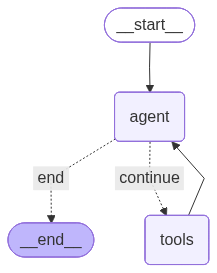

In [27]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [31]:
def print_stream(stream):
    """Helper function for formatting the stream nicely."""
    for s in stream:
        message = s["messages"][-1]
        if isinstance(message, tuple):
            print(message)
        else:
            message.pretty_print()

inputs = {"messages": [HumanMessage(content="What's the weather like in Zurich, and what should I wear based on the temperature?")]}

print_stream(graph.stream(inputs, stream_mode="values"))

================================ Human Message =================================

What's the weather like in Zurich, and what should I wear based on the temperature?
================================== Ai Message ==================================
Tool Calls:
  search_query (r05a6f0gp)
 Call ID: r05a6f0gp
  Args:
    query: Zurich weather
  recommend_clothing (5s1vy70zs)
 Call ID: 5s1vy70zs
  Args:
    weather: current weather in Zurich
================================= Tool Message =================================
Name: recommend_clothing

"A light jacket should be fine."
================================== Ai Message ==================================
Tool Calls:
  recommend_clothing (tykt5c96q)
 Call ID: tykt5c96q
  Args:
    weather: light rain, 8 degrees Celsius
================================= Tool Message =================================
Name: recommend_clothing

"Bring a raincoat and waterproof shoes."
================================== Ai Message =============================

RateLimitError: Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.3-70b-versatile` in organization `org_01kfkdwhjmf57raw4pssj181w7` service tier `on_demand` on tokens per day (TPD): Limit 100000, Used 99976, Requested 5878. Please try again in 1h24m17.856s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}